In [1]:
from model import DyMoTree
from utils import seed_all
seed_all(1, deterministic=True)
dmt = DyMoTree(d_path='/data02/work/wangjiayi/Data/scRNA/CD8/truth',
                 task='CD8',
                 n_neighbor=50,
                 device='cuda')  

[2025-11-05 14:40:57] loading node data for EE
[2025-11-05 14:40:58] loading node data for MP
[2025-11-05 14:41:01] loading node data for TE
[2025-11-05 14:41:03] calculate shortest distance for EE with all descendant


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  40 out of  64 | elapsed:    7.9s remaining:    4.7s
[Parallel(n_jobs=-1)]: Done  47 out of  64 | elapsed:    8.1s remaining:    2.9s
[Parallel(n_jobs=-1)]: Done  54 out of  64 | elapsed:   10.3s remaining:    1.9s
[Parallel(n_jobs=-1)]: Done  61 out of  64 | elapsed:   10.4s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:   10.5s finished


[2025-11-05 14:41:17] loading edge data for EE


In [2]:
seed_all(976, deterministic=True)
dmt.test(task='DMT+s1+s2',
            intra=0.5,inter=0.5,W=0.,
            pre_lr=1e-3,
            pre_iter=500,
            lr=1e-4,
            n_iter=500)
dmt.get_fate_sapce()

:: Stage1 Pre-training -- intra-graph::
:: Do pre-train Graph encoder for EE::


100%|█████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.88it/s, loss=0.776]


:: Do pre-train Graph encoder for MP::


100%|█████████████████████████████████████████████████| 100/100 [00:31<00:00,  3.14it/s, loss=0.965]


:: Do pre-train Graph encoder for TE::


...

:: Stage2 Pre-training -- lineage-graph::


Iter: 500/500 : 100%|█████████████████████████████████| 500/500 [04:53<00:00,  1.71it/s, loss=0.662]


:: DyMoTree Training::


Iter: 500/500 : 100%|██████████████████████████████████| 500/500 [04:54<00:00,  1.70it/s, loss=1.07]


[2025-11-05 14:52:05] get fate space of EE


In [ ]:
from utils import get_metric1
get_metric1(dmt,'fate')

[0.8404439466449446,
 0.7601476014760148,
 0.7096683808016877,
 0.5876976288586551,
 0.538278253883701]

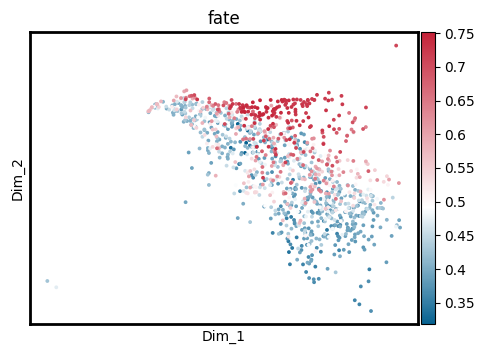

In [5]:
import scanpy as sc
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

#dmt.tree_data.G.nodes['ICM']['data'].adata.obs['fate'] = dmt.tree_data.G.nodes['ICM']['data'].adata.obs['EPI_fate']/(dmt.tree_data.G.nodes['ICM']['data'].adata.obs['PrE_fate']+dmt.tree_data.G.nodes['ICM']['data'].adata.obs['EPI_fate'])
#dmt.tree_data.G.nodes['HSPC']['data'].adata.obs['fate'] = dmt.tree_data.G.nodes['HSPC']['data'].adata.obs['Monocyte_fate']/(dmt.tree_data.G.nodes['HSPC']['data'].adata.obs['Monocyte_fate']+dmt.tree_data.G.nodes['HSPC']['data'].adata.obs['Neutrophil_fate'])
#dmt.tree_data.G.nodes['Transitional']['data'].adata.obs['fate'] = dmt.tree_data.G.nodes['Transitional']['data'].adata.obs['EMT_fate']/(dmt.tree_data.G.nodes['Transitional']['data'].adata.obs['EMT_fate']+dmt.tree_data.G.nodes['Transitional']['data'].adata.obs['AT1_fate'])
dmt.tree_data.G.nodes['EE']['data'].adata.obs['fate'] = dmt.tree_data.G.nodes['EE']['data'].adata.obs['TE_fate']/(dmt.tree_data.G.nodes['EE']['data'].adata.obs['TE_fate']+dmt.tree_data.G.nodes['EE']['data'].adata.obs['MP_fate'])
#dmt.tree_data.G.nodes['Pre']['data'].adata.obs['fate'] = dmt.tree_data.G.nodes['Pre']['data'].adata.obs['Mem_fate']/(dmt.tree_data.G.nodes['Pre']['data'].adata.obs['Mem_fate']+dmt.tree_data.G.nodes['Pre']['data'].adata.obs['Cyto_fate'])

custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.4,"white"), (1,"#c42238")]
)
state_color = {
    'TE_fate': '#b1d7f2',
    'MP_fate': '#f8cbe0',
    'EE': '#64499d'
}
#dmt.tree_data.G.nodes['ICM']['data'].adata.obs['fate1'] = pd.DataFrame(dmt.tree_data.tree['ICM']['prior_list']['prior'])['EPI'].values/(pd.DataFrame(dmt.tree_data.tree['ICM']['prior_list']['prior'])['EPI'].values+pd.DataFrame(dmt.tree_data.tree['ICM']['prior_list']['prior'])['PrE'].values)
#dmt.tree_data.G.nodes['Transitional']['data'].adata.obs['fate1'] = pd.DataFrame(dmt.tree_data.tree['Transitional']['prior_list']['prior'])['EMT'].values/(pd.DataFrame(dmt.tree_data.tree['Transitional']['prior_list']['prior'])['EMT'].values+pd.DataFrame(dmt.tree_data.tree['Transitional']['prior_list']['prior'])['AT1'].values)
#dmt.tree_data.G.nodes['HSPC']['data'].adata.obs['fate1'] = pd.DataFrame(dmt.tree_data.tree['HSPC']['prior_list']['prior'])['Monocyte'].values/(pd.DataFrame(dmt.tree_data.tree['HSPC']['prior_list']['prior'])['Monocyte'].values+pd.DataFrame(dmt.tree_data.tree['HSPC']['prior_list']['prior'])['Neutrophil'].values)
dmt.tree_data.G.nodes['EE']['data'].adata.obs['fate1'] = pd.DataFrame(dmt.tree_data.tree['EE']['prior_list']['prior'])['TE'].values/(pd.DataFrame(dmt.tree_data.tree['EE']['prior_list']['prior'])['TE'].values+pd.DataFrame(dmt.tree_data.tree['EE']['prior_list']['prior'])['MP'].values)
#dmt.tree_data.G.nodes['Pre']['data'].adata.obs['fate1'] = pd.DataFrame(dmt.tree_data.tree['Pre']['prior_list']['prior'])['Mem'].values/(pd.DataFrame(dmt.tree_data.tree['Pre']['prior_list']['prior'])['Mem'].values+pd.DataFrame(dmt.tree_data.tree['Pre']['prior_list']['prior'])['Cyto'].values)

with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        dmt.tree_data.G.nodes['EE']['data'].adata,
        x='Dim_1',
        y='Dim_2',
        color='fate', 
        size=30,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

In [ ]:
import random
import pandas as pd
from utils import  seed_all,get_metric1
r = 0
run = 20
metric = pd.DataFrame(columns=['AUROC','Accuracy','F1-score','Pearson','Spearman'])
seeds = [392,375,426,192,410,474,426,628,488,808,777,289,306,1019,532,891,556,824,125,976]#[random.randint(0, 2**10 - 1) for _ in range(run)]
#[392,375,426,192,410,474,426,628,488,808,777,289,306,1019,532,891,556,824,125,976]
for i in seeds:
    seed_all(i, deterministic=True)
    dmt.train(
            lamda1=0.5,lamda2=0.5,lamda3=0.,lamda4=0,
            k=1e-4, # best: 0
            c=1,  # best: 0.1
            e=0,   # best: 10
            b=0, # best: 1e-4
            n_iter=500,
            pre_iter=500,
            lr=1e-4,
            pre_lr=1e-3)
    dmt.get_fate_sapce()
    metric.loc[r] = get_metric1(dmt,'fate')
    r+=1

:: Do pre-train Graph encoder for EE::


100%|█████████████████████████████████████████████████| 100/100 [00:08<00:00, 11.50it/s, loss=0.844]


:: Do pre-train Graph encoder for MP::


100%|█████████████████████████████████████████████████| 100/100 [00:31<00:00,  3.14it/s, loss=0.955]


:: Do pre-train Graph encoder for TE::


...

:: DyMoTree stage1 tranning ::


Iter: 500/500 : 100%|█████████████████████████████████| 500/500 [04:54<00:00,  1.70it/s, loss=0.662]


:: DyMoTree stage2 tranning ::


Iter: 500/500 : 100%|██████████████████████████████████| 500/500 [06:03<00:00,  1.38it/s, loss=1.35]


[2025-11-05 04:24:42] get fate space of EE


In [6]:
metric

,AUROC,Accuracy,F1-score,Pearson,Spearman
0,0.833296,0.683579,0.648374,0.530420,0.492346
1,0.843270,0.748155,0.700866,0.575475,0.527729
2,0.838968,0.751845,0.704733,0.572233,0.530056
3,0.816409,0.691882,0.653686,0.516391,0.484575
4,0.854485,0.759225,0.713010,0.592410,0.538712
5,0.842379,0.746310,0.699716,0.576910,0.524982
6,0.838968,0.751845,0.704733,0.572233,0.530056
7,0.837659,0.754613,0.707253,0.571009,0.523645
8,0.837547,0.750923,0.701253,0.572067,0.526607
9,0.835918,0.750923,0.704410,0.565270,0.519765


In [3]:
metric.to_csv('./Fig2/2.CD8.DMT.bench.result/performance_new.csv')

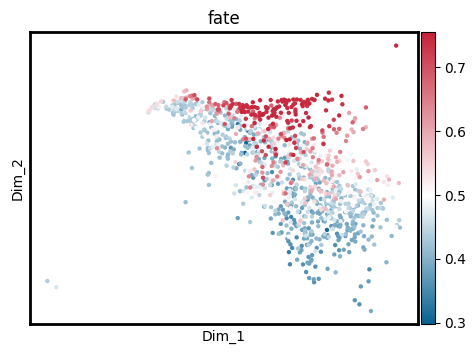

In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
dmt.tree_data.G.nodes['EE']['data'].adata.obs['fate'] = dmt.tree_data.G.nodes['EE']['data'].adata.obs['TE_fate']/(dmt.tree_data.G.nodes['EE']['data'].adata.obs['TE_fate']+dmt.tree_data.G.nodes['EE']['data'].adata.obs['MP_fate'])
dmt.tree_data.G.nodes['EE']['data'].adata.obs['fate1'] = pd.DataFrame(dmt.tree_data.tree['EE']['prior_list']['prior'])['TE'].values/(pd.DataFrame(dmt.tree_data.tree['EE']['prior_list']['prior'])['TE'].values+pd.DataFrame(dmt.tree_data.tree['EE']['prior_list']['prior'])['MP'].values)

median_loc = np.where(dmt.tree_data.G.nodes['EE']['data'].adata.obs['fate']<0.5)[0].shape[0]/dmt.tree_data.G.nodes['EE']['data'].adata.obs.shape[0]
if median_loc<0.5:
    correct_loc = 1-median_loc
else:
    correct_loc = median_loc


custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.44,"white"), (1,"#c42238")]
)
state_color = {
    'Child1_fate': '#b1d7f2',
    'Child2_fate': '#f8cbe0',
    'Stem': '#64499d'
}
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        dmt.tree_data.G.nodes['EE']['data'].adata,
        x='Dim_1',
        y='Dim_2',
        color='fate', 
        size=40,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

In [5]:
# find cell state
seed_all(99, deterministic=True)
dmt.find_state(n_state=2,
               n_pca=5,
               n_diff=5,
               n_gene=5,
               method='spearman')

[2025-11-05 13:33:40] find cell state of EE
[2025-11-05 13:33:41] Filtering Data by fate space


/home/wangjiayi/.conda/envs/dymotree/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


[2025-11-05 13:33:44] PCA transformation
[2025-11-05 13:33:45] Run Diffusion map
[2025-11-05 13:33:46] Find archetypes


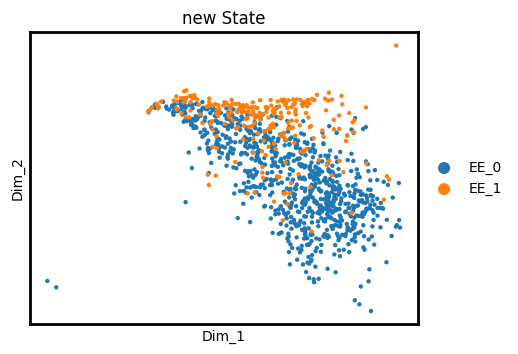

In [6]:
with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        dmt.tree_data.G.nodes['EE']['data'].adata,
        x='Dim_1',
        y='Dim_2',
        color='new_State', 
        size=40,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

/tmp/ipykernel_1348991/3307525625.py:18: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].replace(replacement_map)


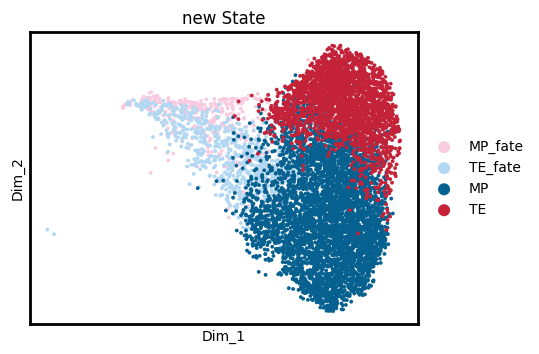

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import scanpy as sc
import anndata
import pandas as pd

adata_merged = anndata.concat(
    [dmt.tree_data.G.nodes[cell]['data'].adata for cell in dmt.init_tree.keys()]
)
adata_to_plot = adata_merged.copy()

# rename DyMoTree Cell State
import pandas as pd
replacement_map = {'EE_0': 'TE_fate', 'EE_1': 'MP_fate','TE':'TE','MP':'MP'}
new_order = ['MP_fate','TE_fate','MP','TE']
adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].astype('category')
adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].replace(replacement_map)
adata_to_plot.obs['new_State'] = adata_to_plot.obs['new_State'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))

adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype('category')
new_order = ['MP','TE','EE']
adata_to_plot.obs['lineage'] = adata_to_plot.obs['lineage'].astype(pd.CategoricalDtype(categories=new_order, ordered=True))


color_map_state = {
    'TE_fate': '#b1d7f2',
    'MP_fate': '#f8cbe0',
    'MP':'#066190',
    'TE':'#c42238'
}
color_map_celltype = {
    'EE': '#64499d',
    'MP':'#066190',
    'TE':'#c42238'
}
state_color_list = [color_map_state[cat] for cat in adata_to_plot.obs['new_State'].cat.categories]
adata_to_plot.uns['new_State_colors'] = state_color_list


celltype_color_list = [color_map_celltype[cat] for cat in adata_to_plot.obs['lineage'].cat.categories]
adata_to_plot.uns['lineage_colors'] = celltype_color_list


with rc_context({'figure.figsize': (5, 4)}):
    ax = sc.pl.scatter(
        adata_to_plot,
        x='Dim_1',
        y='Dim_2',
        color='new_State',  
        size=30,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.show()

In [36]:
dmt.save_model('./Fig2/2.CD8.DMT.bench.result/dmt.pt')
adata_to_plot.write('./Fig2/2.CD8.DMT.bench.result/CD8_dmt.h5ad')
dmt.tree_data.G.nodes['EE']['data'].adata.write('./Fig2/2.CD8.DMT.bench.result/EE_dmt.h5ad')

In [12]:
import pandas as pd
cospar_res = pd.read_csv('./cospar_res.csv')

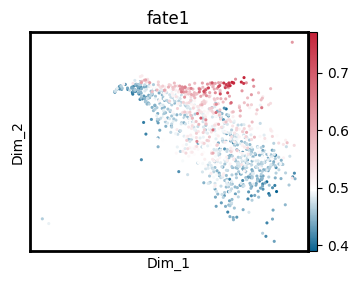

In [18]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt

tree = sc.read('./CD8_dmt.h5ad')
stem = sc.read('./EE_dmt.h5ad')
stem.obs['fate1'] = cospar_res['TE_fate'].values/(cospar_res['TE_fate'].values+cospar_res['MP_fate'].values)
median_loc = np.where(stem.obs['fate']<0.5)[0].shape[0]/stem.obs.shape[0]
if median_loc<0.5:
    correct_loc = 1-median_loc
else:
    correct_loc = median_loc
custom_bwr = mcolors.LinearSegmentedColormap.from_list(
    "custom_bwr", 
    [(0,"#066190"), (0.28,"white"), (1,"#c42238")]
)
gene = 'Cd7'
with rc_context({'figure.figsize': (4, 3)}):
    ax = sc.pl.scatter(
        stem,
        x='Dim_1',
        y='Dim_2',
        color='fate1', 
        size=20,
        color_map=custom_bwr,
        frameon=False,
        show=False
    )
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    plt.savefig(f"./Cospar.CD8.EE.fate_bias.png",bbox_inches='tight')
    plt.show()

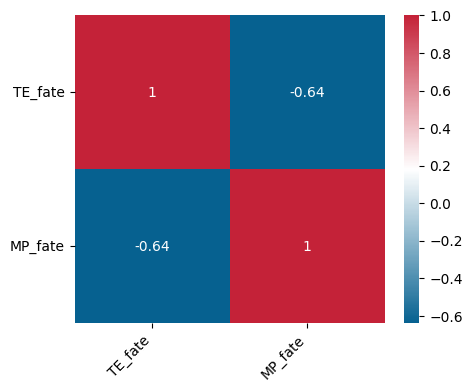

In [38]:
# check fate correlation

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from model import DyMoTree
#dmt = DyMoTree(d_path='/data02/work/wangjiayi/Project_Data/scRNA/LungCancer/Data.DyMoTree/',
#                 task='LC',
#                 n_neighbor=50,
#                 device='cuda') 
#dmt.load_model('./Fig4/dmt.pt')
#dmt.get_fate_sapce()


colors = ["#066190", "white", "#c42238"]
cmap = LinearSegmentedColormap.from_list('custom_red_white_blue', colors, N=256)
#norm = DivergingNorm(vcenter=0)

cor_mat = dmt.tree_data.G.nodes['EE']['data'].adata.obs.loc[:,['TE_fate','MP_fate']].corr()
column_names = ['TE_fate','MP_fate']
row_names = ['TE_fate','MP_fate']
df = pd.DataFrame(data=cor_mat, index=row_names, columns=column_names)

plt.figure(figsize=(5, 4))
# Seaborn的barplot会返回一个Axes对象
ax = sns.heatmap(df,annot=True,cmap=cmap)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
#plt.savefig("./Fig2/2.CD8.DMT.bench.result/CD8.fate_correlation.pdf",bbox_inches='tight')
plt.show()

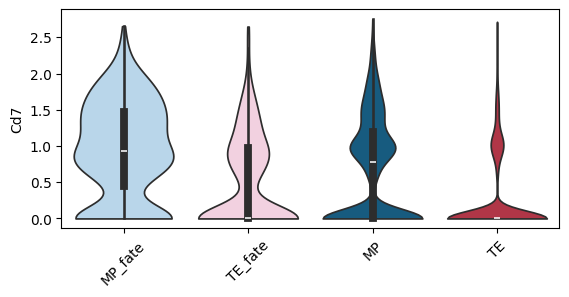

In [ ]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt


tree = sc.read('./Fig2/2.CD8.DMT.bench.result/CD8_dmt.h5ad')
#stem = sc.read('D:/scRNA/LungCancer/Result.DyMoTree.10.14/transitional_dmt.h5ad')
gene = 'Cd7'
with rc_context({'figure.figsize': (6, 3)}):
    ax = sc.pl.violin(
        tree,
        gene,
        groupby='new_State',
        stripplot=False,
        inner='box',
        rotation=45,
        show=False
    )
    #plt.savefig(f"./Fig2/2.CD8.DMT.bench.result/CD8.{gene}_expression.pdf",bbox_inches='tight')
    plt.show()

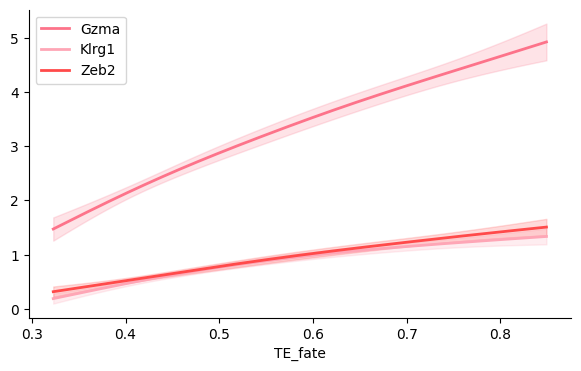

In [ ]:
# plotting dymotree analysed anndata object
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import matplotlib.colors as mcolors
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
from pygam import LinearGAM, s

#features = ['Ms4a6b','Tcf7','Cd7']
#color_map = {features[0]:'#d5e9e2',features[1]:'#a2cae0',features[2]:'#649cc7'}

features = ['Gzma','Klrg1','Zeb2']
color_map = {features[0]:'#fd738a',features[1]:'#fea6b6',features[2]:'#ff4a4a'}
def plot_feature_trend(adata,pseudotime_key,features,color_map,lin_space=200,n_splines=20,lam=50,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(5, 3),show=True):
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    colors = plt.cm.viridis(np.linspace(0, 1, len(features)))
    # --- 4. 循环遍历并绘图 ---
    for i, gene_name in enumerate(features):
    
        x_pseudotime = adata.obs[pseudotime_key].values
        if gene_name in adata.var_names:
            y_expression = adata[:, gene_name].X.toarray().flatten() if hasattr(adata[:, gene_name].X, 'toarray') else adata[:, gene_name].X.flatten()
        else:
            y_expression = adata.obs[gene_name].values

        if len(x_pseudotime) < 15:
            continue
            
        gam = LinearGAM(s(0, n_splines=n_splines, lam=lam)).fit(x_pseudotime, y_expression)
        x_smooth = np.linspace(x_pseudotime.min(), x_pseudotime.max(), lin_space)
        y_smooth = gam.predict(x_smooth)
        intervals = gam.confidence_intervals(x_smooth, width=confidence_level)
        
        
        # 1. 绘制趋势线，并为其分配 label 以便生成图例
        ax.plot(
            x_smooth, 
            y_smooth, 
            linewidth=linewidth, 
            label=gene_name,  # <-- 关键：label 在这里
            color=color_map[gene_name]
        )
        
        # 2. 绘制置信区间，不分配 label
        ax.fill_between(
            x_smooth, 
            intervals[:, 0], 
            intervals[:, 1], 
            color=color_map[gene_name],
            alpha=alpha 
        )
    # 去掉顶部和右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.set_ylabel('Gene Expression')
    ax.set_xlabel(pseudotime_key)
    ax.legend()
    if show:
        # --- 6. 最终调整 ---
        plt.tight_layout()
        plt.show()
    else:
        return ax
ax = plot_feature_trend(stem,'TE_fate',features,color_map,lin_space=1000,n_splines=10,lam=100,confidence_level = 0.95,alpha=0.2,linewidth=2.0,figsize=(7, 4),show=False)
#plt.savefig("./Fig2/2.CD8.DMT.bench.result/CD8.TE_marker_trends.pdf",bbox_inches='tight')
plt.show()